# DiD

In [1]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 3, Finished, Available, Finished, False)

In [2]:
%run ./did_model

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 4, Finished, Available, Finished, True)

In [3]:
# Settings
match_method = "summary_4"
outcome_col = "top3_mean_consumption"

EVENT_WINDOW = (-12, 12)
REFERENCE_EVENT_TIME = -1

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 5, Finished, Available, Finished, False)

In [4]:
# Read data
matches = pd.read_parquet(
    f"/lakehouse/default/Files/output/matching_high/{match_method}/matches"
)

month_result = pd.read_parquet(
    "/lakehouse/default/Files/month_data"
)

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 6, Finished, Available, Finished, False)

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 7, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 148


Running cohort 2025-12, treated households = 121


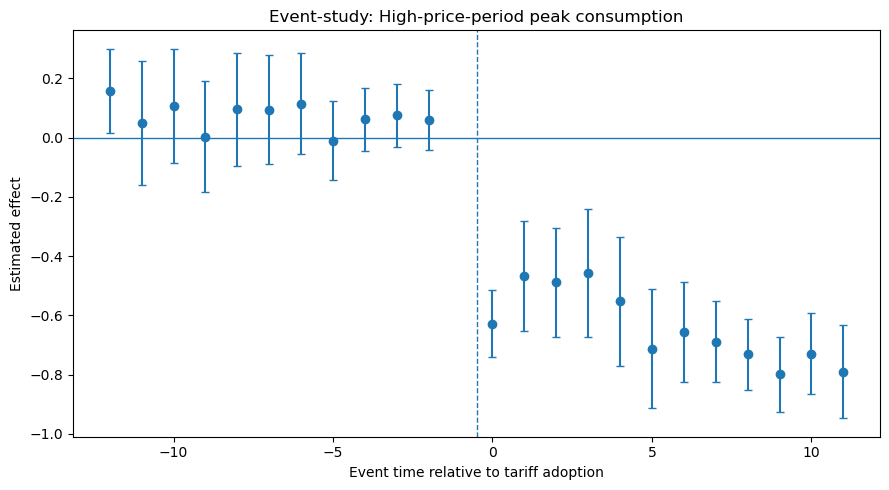

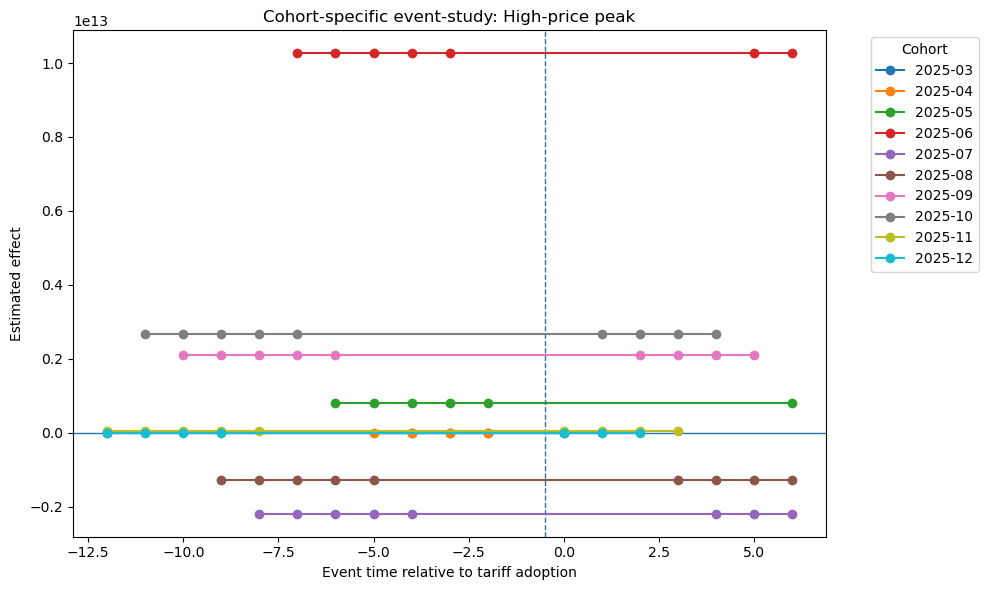

In [5]:
price_value = "high"

df_high = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_high = build_matched_panel(
    matches=matches,
    month_result=df_high,
    outcome_col=outcome_col
)

model_high, result_high = run_basic_did_one(
    matched_high,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models, cohort_basic_results_df = run_basic_did_by_cohort(
    df=matched_high,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_high, event_results_high = run_event_study_one(
    matched_high,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models, cohort_event_results_df = run_event_study_by_cohort(
    df=matched_high,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_high,
    outcome_col=outcome_col,
    title="Event-study: High-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: High-price peak"
)

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 8, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 148


Running cohort 2025-12, treated households = 121


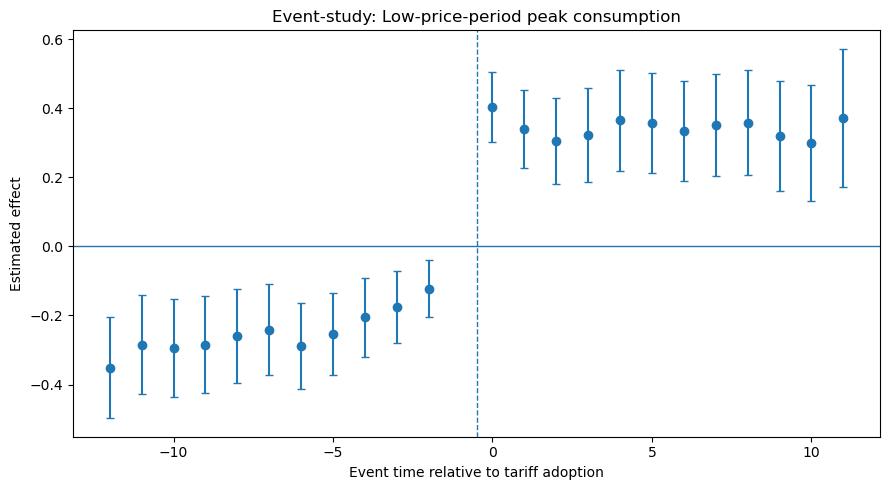

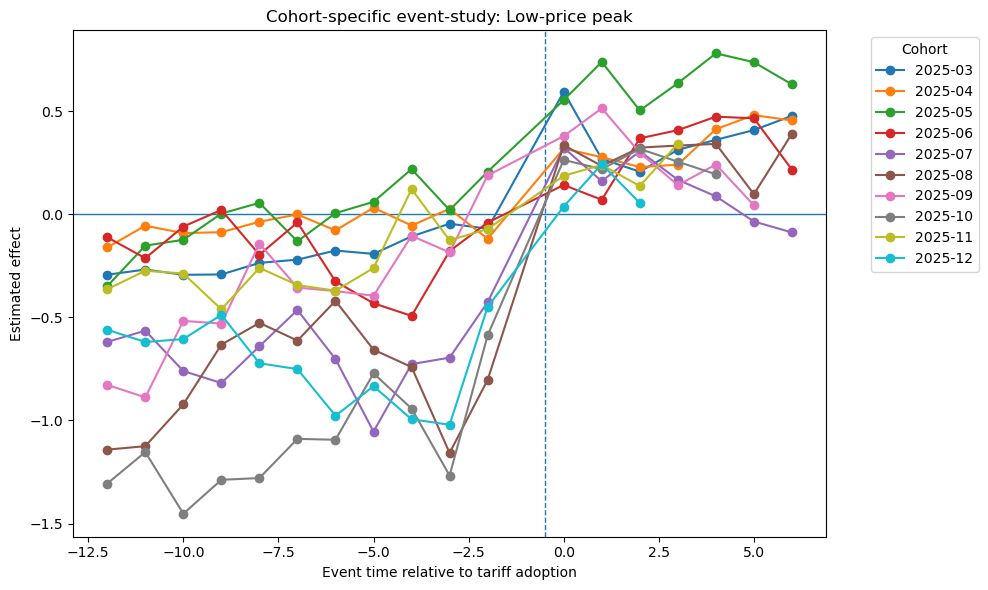

In [6]:
# ============================================================
# LOW PRICE PERIOD
# ============================================================

price_value = "low"

df_low = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_low = build_matched_panel(
    matches=matches,
    month_result=df_low,
    outcome_col=outcome_col
)

model_low, result_low = run_basic_did_one(
    matched_low,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models_low, cohort_basic_results_df_low = run_basic_did_by_cohort(
    df=matched_low,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_low, event_results_low = run_event_study_one(
    matched_low,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models_low, cohort_event_results_df_low = run_event_study_by_cohort(
    df=matched_low,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_low,
    outcome_col=outcome_col,
    title="Event-study: Low-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df_low,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: Low-price peak"
)

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 9, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 148


Running cohort 2025-12, treated households = 121


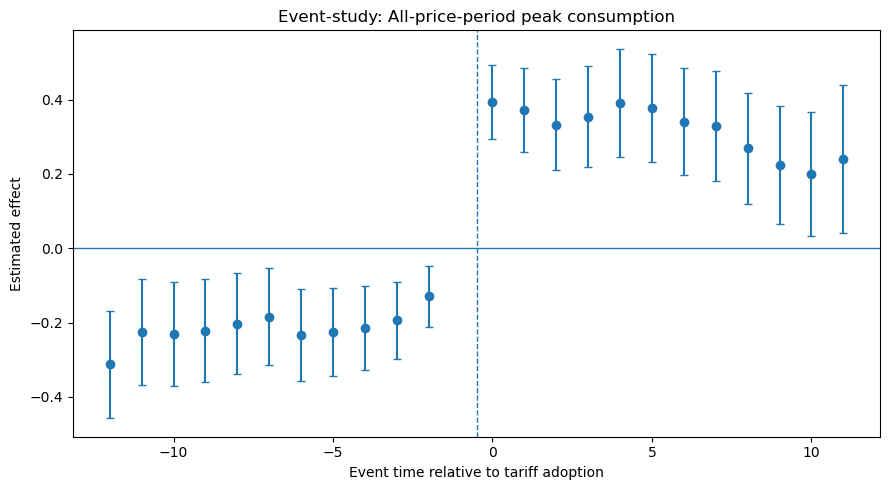

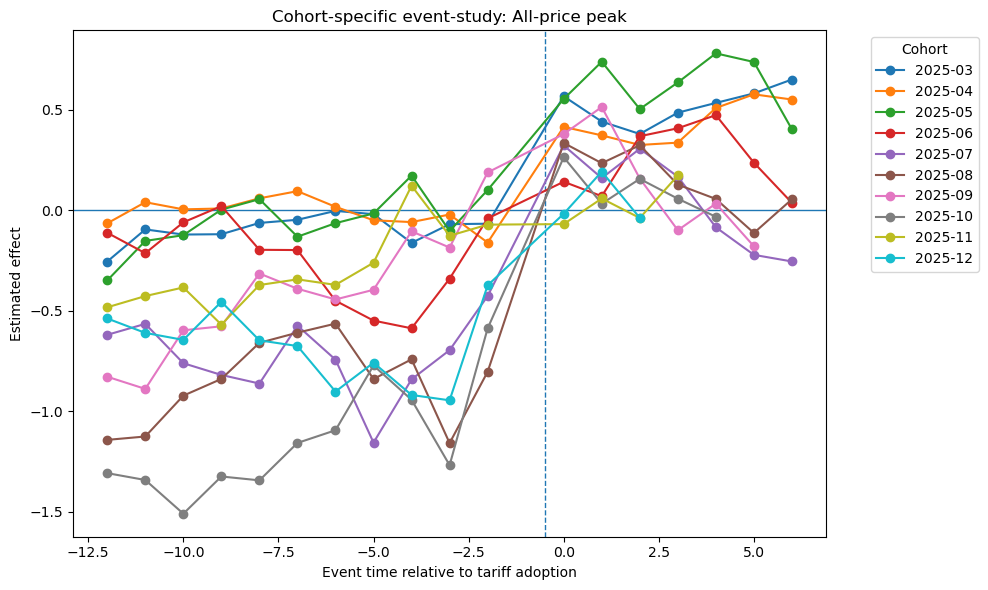

In [7]:
# ============================================================
# ALL PRICE PERIOD
# ============================================================

price_value = "all"

df_all = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_all = build_matched_panel(
    matches=matches,
    month_result=df_all,
    outcome_col=outcome_col
)

model_all, result_all = run_basic_did_one(
    matched_all,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models_all, cohort_basic_results_df_all = run_basic_did_by_cohort(
    df=matched_all,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_all, event_results_all = run_event_study_one(
    matched_all,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models_all, cohort_event_results_df_all = run_event_study_by_cohort(
    df=matched_all,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_all,
    outcome_col=outcome_col,
    title="Event-study: All-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df_all,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: All-price peak"
)

In [9]:
# ============================================================
# HIGH PRICE PERIOD
# ============================================================

print_result_table(
    result_high,
    title="HIGH PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df,
    title="HIGH PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_high,
    title="HIGH PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df,
    title="HIGH PRICE PERIOD — Cohort-specific Event-study"
)



StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 11, Finished, Available, Finished, False)


HIGH PRICE PERIOD — Basic DiD
              outcome    coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption -0.8306       0.04      0.0    -0.909   -0.7523 167393        9871

HIGH PRICE PERIOD — Cohort-specific DiD
 cohort               outcome    coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption -0.9696     0.0636   0.0000   -1.0943   -0.8449        625          5  59891        3533
2025-04 top3_mean_consumption -0.6977     0.0841   0.0000   -0.8625   -0.5329        334          4  33095        1951
2025-05 top3_mean_consumption -0.9509     0.1473   0.0000   -1.2397   -0.6621        140          4  14192         836
2025-06 top3_mean_consumption -0.8220     0.1539   0.0000   -1.1236   -0.5204        125          4  12562         742
2025-07 top3_mean_consumption -1.0151     0.2356   0.0000   -1.4769   -0.5532         64          4   6420         378
2025-08 top3_mean_consumption -1.053

In [10]:

# ============================================================
# LOW PRICE PERIOD
# ============================================================

print_result_table(
    result_low,
    title="LOW PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df_low,
    title="LOW PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_low,
    title="LOW PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df_low,
    title="LOW PRICE PERIOD — Cohort-specific Event-study"
)

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 12, Finished, Available, Finished, False)


LOW PRICE PERIOD — Basic DiD
              outcome   coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption 0.6282     0.0577      0.0    0.5151    0.7412 374079        9871

LOW PRICE PERIOD — Cohort-specific DiD
 cohort               outcome   coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption 0.6647     0.0931   0.0000    0.4823    0.8471        625         12 133845        3533
2025-04 top3_mean_consumption 0.5391     0.1219   0.0000    0.3001    0.7781        334         11  73971        1951
2025-05 top3_mean_consumption 0.8131     0.2161   0.0002    0.3895    1.2367        140         10  31693         836
2025-06 top3_mean_consumption 0.3976     0.2123   0.0611   -0.0186    0.8137        125          9  28063         742
2025-07 top3_mean_consumption 0.8403     0.3339   0.0118    0.1859    1.4947         64          8  14345         378
2025-08 top3_mean_consumption 1.1610     0.342

In [11]:


# ============================================================
# ALL PRICE PERIOD
# ============================================================

print_result_table(
    result_all,
    title="ALL PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df_all,
    title="ALL PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_all,
    title="ALL PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df_all,
    title="ALL PRICE PERIOD — Cohort-specific Event-study"
)
     

StatementMeta(, 223511ce-f0f9-4d84-a65b-419ad198994e, 13, Finished, Available, Finished, False)


ALL PRICE PERIOD — Basic DiD
              outcome  coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption 0.596     0.0574      0.0    0.4834    0.7085 374079        9871

ALL PRICE PERIOD — Cohort-specific DiD
 cohort               outcome   coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption 0.6435     0.0927   0.0000    0.4618    0.8252        625         12 133845        3533
2025-04 top3_mean_consumption 0.5215     0.1214   0.0000    0.2836    0.7593        334         11  73971        1951
2025-05 top3_mean_consumption 0.7674     0.2142   0.0003    0.3476    1.1873        140         10  31693         836
2025-06 top3_mean_consumption 0.3625     0.2120   0.0873   -0.0530    0.7780        125          9  28063         742
2025-07 top3_mean_consumption 0.7674     0.3324   0.0210    0.1159    1.4190         64          8  14345         378
2025-08 top3_mean_consumption 1.0412     0.3394 